# FMCG E-Commerce Demand Forecasting Using LSTM

## End-to-End Deep Learning Project

**Objective:** Forecast the next 7 days of FMCG product demand using historical sales data and an LSTM-based global time-series model.

### Project Flow
`Load Data → Validate → Clean → EDA → Aggregate Time Series → Feature Engineering → Time-Based Split → Scale → Sequence Creation → Baseline → LSTM → Evaluation → 7-Day Forecast → Inventory Analysis → Save Model → Streamlit-ready Artifacts`

> **Important:** This notebook is built specifically for `FMCG_2022_2024.csv`. It uses the supplied regression notebook only as a reference for project organization and workflow; the modeling approach here is LSTM time-series forecasting.


## 1. Business Problem

E-commerce/FMCG businesses need to estimate future product demand so that inventory can be planned without excessive stock or stock-outs.

This project uses historical `units_sold` as the demand signal. The data is converted into daily time series for each **SKU × Region** combination. A global LSTM learns temporal patterns across these series and forecasts the **next 7 days**.

### Business Questions
- What demand can be expected over the next 7 days?
- Which SKU/region combinations may face higher demand?
- Is available stock sufficient for the forecasted demand?
- Can the forecast be used as a decision-support signal for replenishment?


## 2. Import Libraries

In [24]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Libraries loaded successfully.")


TensorFlow version: 2.21.0
Libraries loaded successfully.


## 3. Configuration

Change only the paths/parameters below if needed. The notebook is designed to work with the CSV in the same folder as the notebook.

In [25]:
DATA_PATH = "FMCG_2022_2024.csv"

DATE_COL = "date"
TARGET_COL = "units_sold"
GROUP_COLS = ["sku", "region"]

LOOKBACK = 30          # previous 30 days
FORECAST_HORIZON = 7   # next 7 days
TEST_DAYS = 60         # final 60 days used for testing
VAL_DAYS = 30          # last 30 training days used for validation

MODEL_DIR = "fmcg_lstm_artifacts"
os.makedirs(MODEL_DIR, exist_ok=True)

print("Configuration ready.")


Configuration ready.


## 4. Load Dataset

In [26]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}. Put FMCG_2022_2024.csv in the notebook working directory."
    )

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())


Shape: (190757, 14)


,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold
0,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-Central,Multipack,2.38,0,1,141,128,9
1,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-North,Single,1.55,1,3,0,129,0
2,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-South,Carton,4.00,0,5,118,161,8
3,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-Central,Single,5.16,0,2,81,114,7
4,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-North,Single,7.66,0,4,148,204,12


## 5. Data Understanding

In [27]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nDataset info:")
df.info()


Columns:
['date', 'sku', 'brand', 'segment', 'category', 'channel', 'region', 'pack_type', 'price_unit', 'promotion_flag', 'delivery_days', 'stock_available', 'delivered_qty', 'units_sold']

Data types:


,dtype
date,str
sku,str
brand,str
segment,str
category,str
channel,str
region,str
pack_type,str
price_unit,float64
promotion_flag,int64



Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 190757 entries, 0 to 190756
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   date             190757 non-null  str    
 1   sku              190757 non-null  str    
 2   brand            190757 non-null  str    
 3   segment          190757 non-null  str    
 4   category         190757 non-null  str    
 5   channel          190757 non-null  str    
 6   region           190757 non-null  str    
 7   pack_type        190757 non-null  str    
 8   price_unit       190757 non-null  float64
 9   promotion_flag   190757 non-null  int64  
 10  delivery_days    190757 non-null  int64  
 11  stock_available  190757 non-null  int64  
 12  delivered_qty    190757 non-null  int64  
 13  units_sold       190757 non-null  int64  
dtypes: float64(1), int64(5), str(8)
memory usage: 32.3 MB


In [28]:
print("Date range:", df[DATE_COL].min(), "to", df[DATE_COL].max())
print("Unique SKUs:", df["sku"].nunique())
print("Categories:", df["category"].nunique())
print("Channels:", df["channel"].nunique())
print("Regions:", df["region"].nunique())

display(df[["sku", "region"]].drop_duplicates().head(20))


Date range: 2022-01-21 to 2024-12-31
Unique SKUs: 30
Categories: 5
Channels: 3
Regions: 3


,sku,region
0,MI-006,PL-Central
1,MI-006,PL-North
2,MI-006,PL-South
15,MI-026,PL-North
16,MI-026,PL-South
18,MI-026,PL-Central
574,YO-029,PL-North
575,YO-029,PL-South
576,YO-029,PL-Central
855,YO-005,PL-Central


## 6. Data Quality Checks

In [29]:
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")

print("Missing values:")
display(df.isna().sum().to_frame("missing_count"))

print("Duplicate rows:", df.duplicated().sum())

print("\nTarget statistics:")
display(df[TARGET_COL].describe())

print("\nNegative units_sold rows:", (df[TARGET_COL] < 0).sum())


Missing values:


,missing_count
date,0
sku,0
brand,0
segment,0
category,0
channel,0
region,0
pack_type,0
price_unit,0
promotion_flag,0


Duplicate rows: 0

Target statistics:


count    190757.000000
mean         19.919709
std          11.770077
min         -25.000000
25%          12.000000
50%          18.000000
75%          25.000000
max         139.000000
Name: units_sold, dtype: float64


Negative units_sold rows: 3


### Handling Negative Demand Values

`units_sold` contains negative observations. Negative physical sales are not meaningful as demand, so for the forecasting target we clip them to zero.

The original raw dataframe is retained in `df_raw` so the transformation is traceable.

In [30]:
df_raw = df.copy()

negative_count = (df[TARGET_COL] < 0).sum()
df[TARGET_COL] = df[TARGET_COL].clip(lower=0)

print("Negative target values corrected:", negative_count)
print("Remaining negative values:", (df[TARGET_COL] < 0).sum())


Negative target values corrected: 3
Remaining negative values: 0


## 7. Exploratory Data Analysis

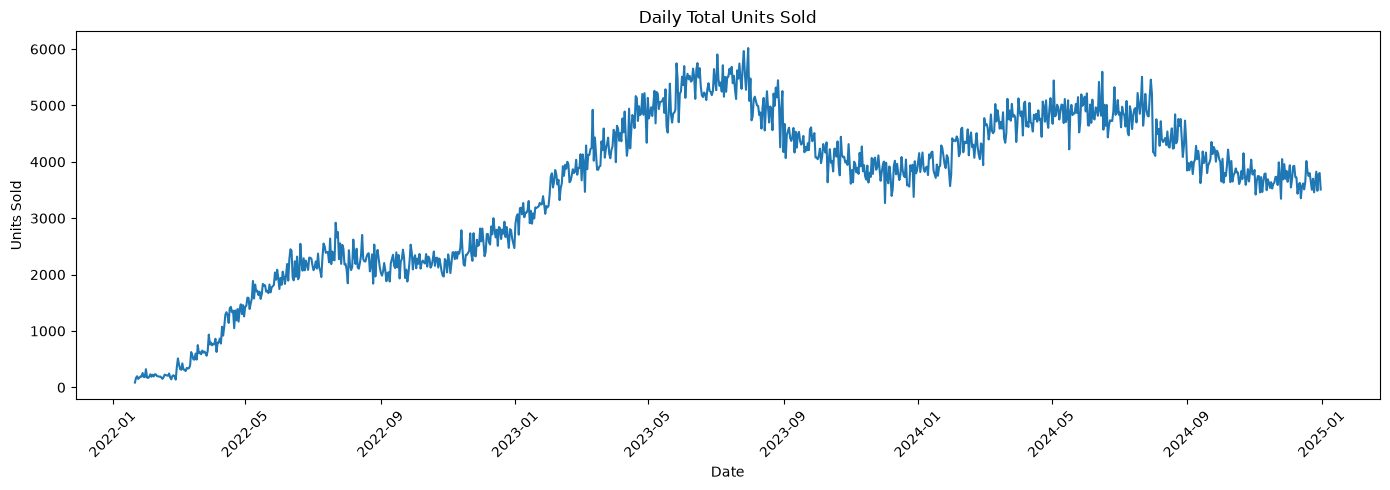

In [31]:
daily_total = df.groupby(DATE_COL)[TARGET_COL].sum()

plt.figure(figsize=(14,5))
plt.plot(daily_total.index, daily_total.values)
plt.title("Daily Total Units Sold")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


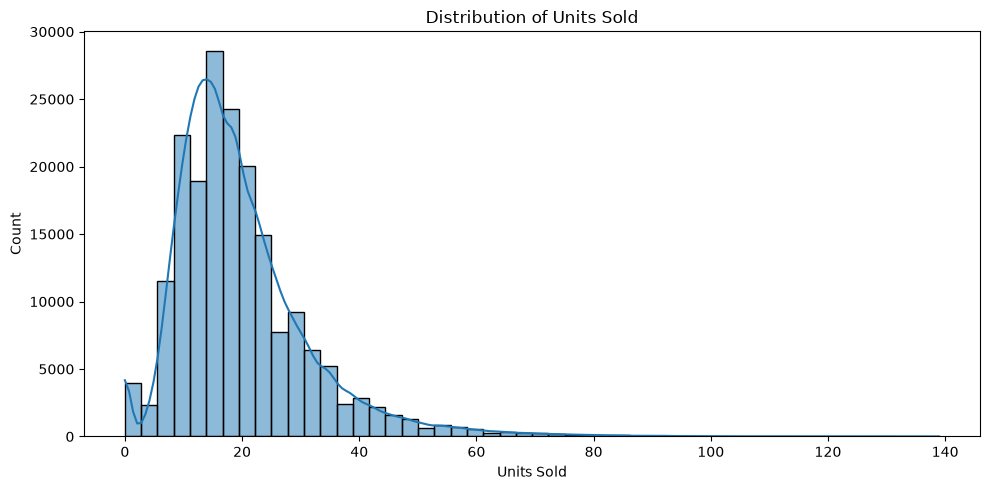

In [32]:
plt.figure(figsize=(10,5))
sns.histplot(df[TARGET_COL], bins=50, kde=True)
plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.tight_layout()
plt.show()


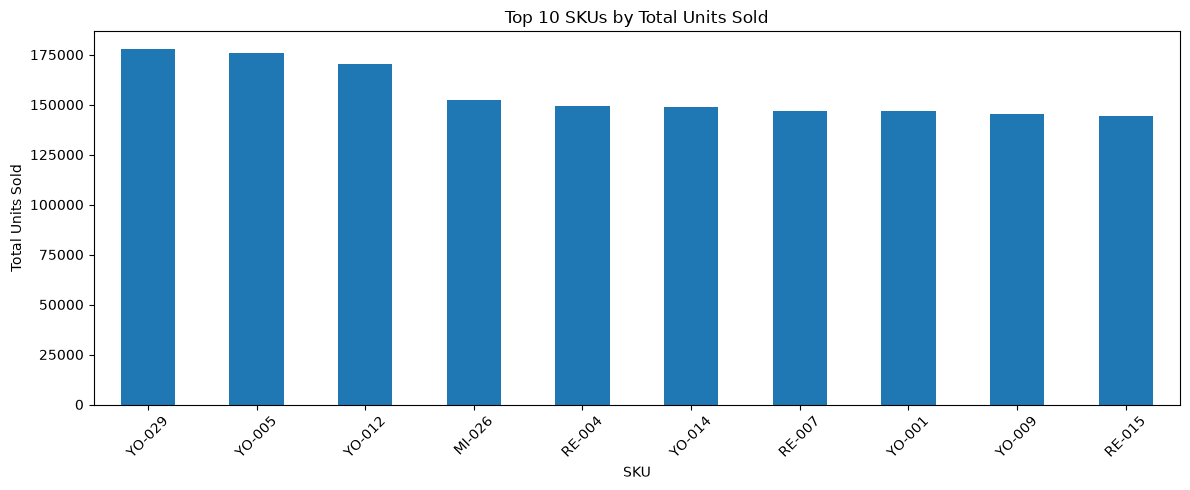

In [33]:
top_skus = (
    df.groupby("sku")[TARGET_COL]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,5))
top_skus.plot(kind="bar")
plt.title("Top 10 SKUs by Total Units Sold")
plt.xlabel("SKU")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


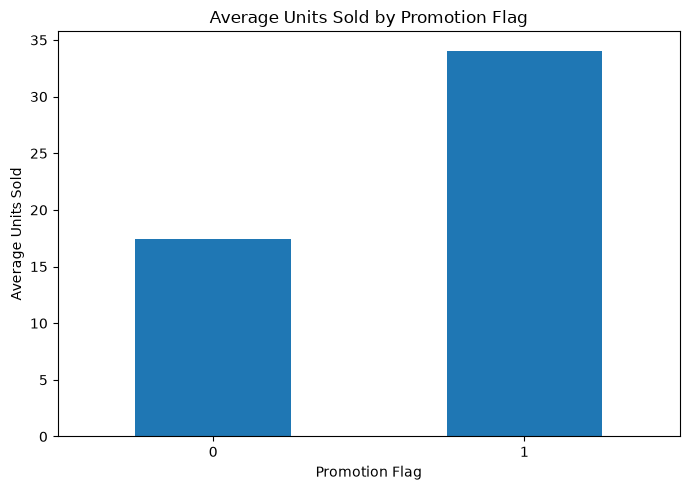

,avg_units_sold
promotion_flag,
0,17.439968
1,34.061453


In [34]:
promo_summary = df.groupby("promotion_flag")[TARGET_COL].mean()

plt.figure(figsize=(7,5))
promo_summary.plot(kind="bar")
plt.title("Average Units Sold by Promotion Flag")
plt.xlabel("Promotion Flag")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(promo_summary.to_frame("avg_units_sold"))


## 8. Prepare Daily SKU × Region Demand

The original data contains multiple transactional rows per day because of channel/pack/product attributes. For a stable demand time series, we aggregate `units_sold` by **date, SKU and region**.

Known operational variables are also aggregated:
- average unit price
- promotion rate
- available stock
- delivered quantity
- average delivery days


In [35]:
daily = (
    df.groupby([DATE_COL, "sku", "region"], as_index=False)
      .agg(
          units_sold=(TARGET_COL, "sum"),
          price_unit=("price_unit", "mean"),
          promotion_rate=("promotion_flag", "mean"),
          stock_available=("stock_available", "sum"),
          delivered_qty=("delivered_qty", "sum"),
          delivery_days=("delivery_days", "mean")
      )
      .sort_values(["sku", "region", DATE_COL])
)

print("Aggregated shape:", daily.shape)
display(daily.head())


Aggregated shape: (74589, 9)


,date,sku,region,units_sold,price_unit,promotion_rate,stock_available,delivered_qty,delivery_days
3373,2022-07-11,JU-021,PL-Central,96,5.046667,0.333333,547,594,3.333333
3409,2022-07-12,JU-021,PL-Central,27,3.306667,0.000000,315,349,3.333333
3445,2022-07-13,JU-021,PL-Central,69,5.196667,0.000000,595,614,1.666667
3481,2022-07-14,JU-021,PL-Central,53,6.376667,0.000000,451,478,4.666667
3517,2022-07-15,JU-021,PL-Central,53,5.543333,0.000000,458,490,2.666667


## 9. Create a Complete Daily Time Series

LSTM sequences require regular time intervals. We reindex each SKU × Region series to daily frequency.

Missing sales observations are treated as zero demand only after the daily aggregation, because the absence of a transaction for a SKU-region-day means no recorded sales in this dataset.

In [36]:
series_list = []

for (sku, region), g in daily.groupby(["sku", "region"]):
    g = g.sort_values(DATE_COL).set_index(DATE_COL)
    full_idx = pd.date_range(g.index.min(), g.index.max(), freq="D")
    g = g.reindex(full_idx)

    g["sku"] = sku
    g["region"] = region

    # Demand: no recorded transaction on a day -> 0 recorded units sold
    g["units_sold"] = g["units_sold"].fillna(0)

    # Other features: time interpolation / carry-forward where appropriate
    for col in ["price_unit", "promotion_rate", "stock_available",
                "delivered_qty", "delivery_days"]:
        g[col] = g[col].interpolate(limit_direction="both")

    g = g.reset_index().rename(columns={"index": DATE_COL})
    series_list.append(g)

ts = pd.concat(series_list, ignore_index=True)
ts = ts.sort_values(["sku", "region", DATE_COL]).reset_index(drop=True)

print("Time-series shape:", ts.shape)
print("Series count:", ts.groupby(["sku", "region"]).ngroups)
display(ts.head())


Time-series shape: (74832, 9)
Series count: 90


,date,sku,region,units_sold,price_unit,promotion_rate,stock_available,delivered_qty,delivery_days
0,2022-07-11,JU-021,PL-Central,96.0,5.046667,0.333333,547.0,594.0,3.333333
1,2022-07-12,JU-021,PL-Central,27.0,3.306667,0.000000,315.0,349.0,3.333333
2,2022-07-13,JU-021,PL-Central,69.0,5.196667,0.000000,595.0,614.0,1.666667
3,2022-07-14,JU-021,PL-Central,53.0,6.376667,0.000000,451.0,478.0,4.666667
4,2022-07-15,JU-021,PL-Central,53.0,5.543333,0.000000,458.0,490.0,2.666667


## 10. Time-Based Feature Engineering

We create calendar features and demand history features. Lag/rolling features are calculated separately within each SKU × Region series to avoid information leakage across products.

In [37]:
ts["day_of_week"] = ts[DATE_COL].dt.dayofweek
ts["is_weekend"] = (ts["day_of_week"] >= 5).astype(int)
ts["month"] = ts[DATE_COL].dt.month
ts["day_of_month"] = ts[DATE_COL].dt.day

grouped = ts.groupby(["sku", "region"], group_keys=False)

ts["lag_1"] = grouped["units_sold"].shift(1)
ts["lag_7"] = grouped["units_sold"].shift(7)
ts["lag_14"] = grouped["units_sold"].shift(14)
ts["lag_30"] = grouped["units_sold"].shift(30)

ts["rolling_mean_7"] = grouped["units_sold"].transform(
    lambda s: s.shift(1).rolling(7, min_periods=1).mean()
)
ts["rolling_mean_14"] = grouped["units_sold"].transform(
    lambda s: s.shift(1).rolling(14, min_periods=1).mean()
)
ts["rolling_mean_30"] = grouped["units_sold"].transform(
    lambda s: s.shift(1).rolling(30, min_periods=1).mean()
)

# Remove the initial rows that do not have a 30-day history.
ts_model = ts.dropna(subset=[
    "lag_1", "lag_7", "lag_14", "lag_30",
    "rolling_mean_7", "rolling_mean_14", "rolling_mean_30"
]).copy()

print("Model-ready rows:", len(ts_model))
display(ts_model.head())


Model-ready rows: 72132


,date,sku,region,units_sold,price_unit,promotion_rate,stock_available,delivered_qty,delivery_days,day_of_week,is_weekend,month,day_of_month,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_30
30,2022-08-10,JU-021,PL-Central,70.0,2.883333,0.333333,529.0,569.0,3.000000,2,0,8,10,75.0,52.0,53.0,96.0,53.428571,45.357143,51.766667
31,2022-08-11,JU-021,PL-Central,20.0,5.480000,0.000000,200.0,299.0,2.000000,3,0,8,11,70.0,80.0,20.0,27.0,56.000000,46.571429,50.900000
32,2022-08-12,JU-021,PL-Central,50.0,6.073333,0.333333,556.0,735.0,3.333333,4,0,8,12,20.0,44.0,44.0,69.0,47.428571,46.571429,50.666667
33,2022-08-13,JU-021,PL-Central,57.0,6.135000,0.500000,244.0,343.0,3.000000,5,1,8,13,50.0,56.0,40.0,53.0,48.285714,47.000000,50.033333
34,2022-08-14,JU-021,PL-Central,44.0,7.266667,0.333333,293.0,533.0,3.000000,6,1,8,14,57.0,52.0,34.0,53.0,48.428571,48.214286,50.166667


## 11. Feature Selection

For the LSTM sequence we use demand history plus operational/context variables.

The categorical identity of the SKU/region is represented through separate time-series groups. The global LSTM is trained across all groups so that it can learn common temporal patterns.

In [38]:
FEATURE_COLS = [
    "units_sold",
    "price_unit",
    "promotion_rate",
    "stock_available",
    "delivered_qty",
    "delivery_days",
    "day_of_week",
    "is_weekend",
    "month",
    "day_of_month",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30"
]

TARGET_INDEX = FEATURE_COLS.index("units_sold")

print("Number of features:", len(FEATURE_COLS))
print(FEATURE_COLS)


Number of features: 17
['units_sold', 'price_unit', 'promotion_rate', 'stock_available', 'delivered_qty', 'delivery_days', 'day_of_week', 'is_weekend', 'month', 'day_of_month', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30']


## 12. Chronological Train / Validation / Test Split

Time-series data must **not** be randomly shuffled.

For each SKU × Region series:
- final `TEST_DAYS` = test set
- preceding `VAL_DAYS` = validation set
- earlier observations = training set

This prevents future observations from leaking into model training.

In [39]:
def split_series(g):
    g = g.sort_values(DATE_COL).copy()
    n = len(g)
    if n <= LOOKBACK + TEST_DAYS + VAL_DAYS:
        return None, None, None

    train_end = n - TEST_DAYS - VAL_DAYS
    val_end = n - TEST_DAYS

    return (
        g.iloc[:train_end].copy(),
        g.iloc[train_end:val_end].copy(),
        g.iloc[val_end:].copy()
    )

train_parts, val_parts, test_parts = [], [], []

for key, g in ts_model.groupby(["sku", "region"]):
    result = split_series(g)
    if result is None:
        continue
    a, b, c = result
    train_parts.append(a)
    val_parts.append(b)
    test_parts.append(c)

train_df = pd.concat(train_parts, ignore_index=True)
val_df = pd.concat(val_parts, ignore_index=True)
test_df = pd.concat(test_parts, ignore_index=True)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)
print("Train end:", train_df[DATE_COL].max())
print("Validation:", val_df[DATE_COL].min(), "to", val_df[DATE_COL].max())
print("Test start:", test_df[DATE_COL].min())


Train: (64032, 20)
Validation: (2700, 20)
Test: (5400, 20)
Train end: 2024-10-02 00:00:00
Validation: 2024-10-02 00:00:00 to 2024-11-01 00:00:00
Test start: 2024-11-01 00:00:00


## 13. Scale Features Without Leakage

The scaler is fitted **only on training data**. Validation and test data are transformed using the same training scaler.

In [40]:
scaler = MinMaxScaler()

train_values = train_df[FEATURE_COLS].astype(float).values
val_values = val_df[FEATURE_COLS].astype(float).values
test_values = test_df[FEATURE_COLS].astype(float).values

scaler.fit(train_values)

train_scaled = scaler.transform(train_values)
val_scaled = scaler.transform(val_values)
test_scaled = scaler.transform(test_values)

print("Scaling complete.")


Scaling complete.


## 14. Create LSTM Sequences

Input shape:

`(samples, LOOKBACK, features)`

Target:

`next-day units_sold`

The model first learns one-step forecasting. After training, a recursive 7-day forecasting function generates the next 7 days.

In [45]:
def make_period_sequences(full_scaled, full_frame, target_frame, lookback):
    X, y, meta = [], [], []

    full_frame = (
        full_frame
        .sort_values(["sku", "region", DATE_COL])
        .reset_index(drop=True)
    )

    target_keys = set(
        zip(
            target_frame["sku"],
            target_frame["region"],
            target_frame[DATE_COL]
        )
    )

    for (sku, region), g in full_frame.groupby(["sku", "region"]):

        g = g.sort_values(DATE_COL).reset_index()

        for pos in range(lookback, len(g)):

            target_date = g.loc[pos, DATE_COL]
            target_key = (sku, region, target_date)

            # Only create sequences for validation targets
            if target_key not in target_keys:
                continue

            window_pos = np.arange(pos - lookback, pos)

            global_indices = g.loc[
                window_pos, "index"
            ].to_numpy()

            target_global = int(g.loc[pos, "index"])

            X.append(full_scaled[global_indices])
            y.append(full_scaled[target_global, TARGET_INDEX])

            meta.append(
                (sku, region, target_date)
            )

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        meta
    )


# Combine train + validation + test
all_model_df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

all_model_df = (
    all_model_df
    .drop_duplicates(
        subset=[DATE_COL, "sku", "region"]
    )
    .sort_values(
        ["sku", "region", DATE_COL]
    )
    .reset_index(drop=True)
)

# Scale using the already-fitted training scaler
all_scaled = scaler.transform(
    all_model_df[FEATURE_COLS].astype(float)
)


# Training sequences
X_train, y_train, train_meta = make_sequences(
    train_scaled,
    train_df,
    LOOKBACK,
    len(FEATURE_COLS)
)


# Validation sequences WITH previous training context
X_val, y_val, val_meta = make_period_sequences(
    all_scaled,
    all_model_df,
    val_df,
    LOOKBACK
)


print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (61332, 30, 17)
y_train: (61332,)
X_val: (2700, 30, 17)
y_val: (2700,)


## 15. Baseline Model

Before deep learning, establish a simple baseline: **predict tomorrow's demand using the most recent observed demand**.

This gives a realistic reference point for judging the LSTM.

In [42]:
# Naive baseline on the test period:
# prediction for each test row = its lag_1 value
y_test_actual = test_df[TARGET_COL].values.astype(float)
y_test_naive = test_df["lag_1"].values.astype(float)

baseline_mae = mean_absolute_error(y_test_actual, y_test_naive)
baseline_rmse = np.sqrt(mean_squared_error(y_test_actual, y_test_naive))

print(f"Naive Baseline MAE : {baseline_mae:.4f}")
print(f"Naive Baseline RMSE: {baseline_rmse:.4f}")


Naive Baseline MAE : 18.8948
Naive Baseline RMSE: 24.3679


## 16. Build the LSTM Model

In [43]:
model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, len(FEATURE_COLS))),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.20),
    layers.LSTM(32),
    layers.Dropout(0.20),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 64)         │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,953 (132.63 KB)

 Trainable params: 33,953 (132.63 KB)

 Non-trainable params: 0 (0.00 B)

## 17. Train the LSTM

In [46]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - loss: 0.0077 - mae: 0.0669 - val_loss: 0.0048 - val_mae: 0.0533 - learning_rate: 0.0010
Epoch 2/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.0076 - mae: 0.0663 - val_loss: 0.0048 - val_mae: 0.0533 - learning_rate: 0.0010
Epoch 3/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.0075 - mae: 0.0660 - val_loss: 0.0047 - val_mae: 0.0534 - learning_rate: 0.0010
Epoch 4/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.0075 - mae: 0.0659 - val_loss: 0.0047 - val_mae: 0.0535 - learning_rate: 0.0010
Epoch 5/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.0075 - mae: 0.0658 - val_loss: 0.0047 - val_mae: 0.0535 - learning_rate: 0.0010
Epoch 6/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.0074 - mae: 0.0657 - val_loss: 0.0048 - val_mae: 0.0542 - learning_rate: 5.0000e-04
Epoch 7/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.0074 - mae: 0.0656 - val_loss: 0.0048 - val_mae: 0.0539 - learning_r

## 18. Training History

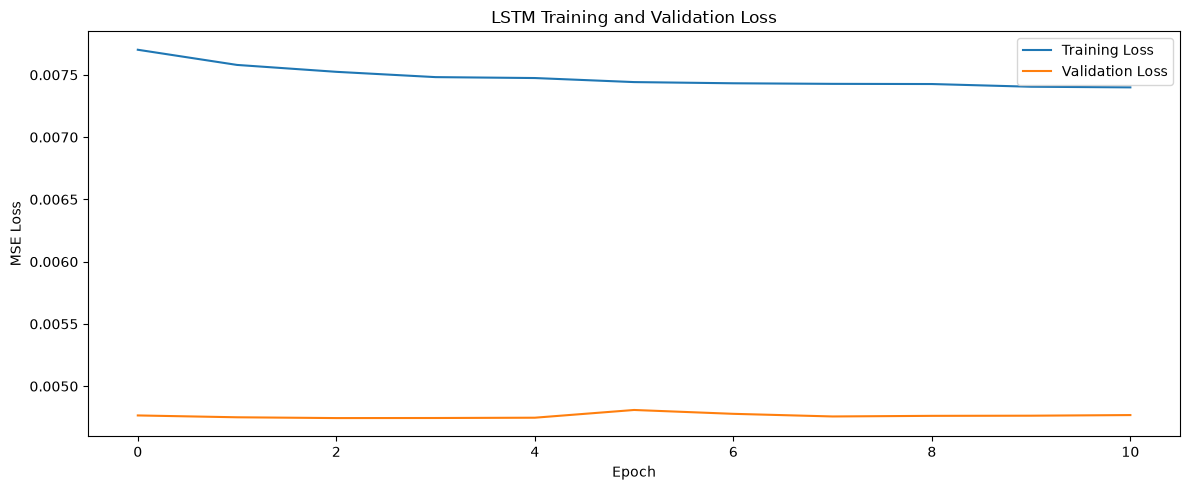

In [47]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(12,5))
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()


## 19. Prepare Test Sequences

Test windows are created from the test period. Because the first test prediction needs historical context, the final `LOOKBACK` rows immediately before the test period are included as context but are not scored as test targets.

In [48]:
def make_test_sequences_with_context(full_scaled, full_frame, test_start_date, lookback):
    X, y, dates, keys = [], [], [], []

    for (sku, region), g in full_frame.groupby(["sku", "region"]):
        g = g.sort_values(DATE_COL).reset_index()
        test_positions = g.index[g[DATE_COL] >= test_start_date].to_numpy()

        if len(test_positions) == 0:
            continue

        first_test = test_positions[0]
        if first_test < lookback:
            continue

        for pos in test_positions:
            window_pos = np.arange(pos-lookback, pos)
            global_indices = g.loc[window_pos, "index"].to_numpy()
            target_global = int(g.loc[pos, "index"])

            X.append(full_scaled[global_indices])
            y.append(full_scaled[target_global, TARGET_INDEX])
            dates.append(g.loc[pos, DATE_COL])
            keys.append((sku, region))

    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32), dates, keys

# Combine model-ready rows to create a continuous scaled frame.
all_model_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
all_model_df = all_model_df.drop_duplicates(
    subset=[DATE_COL, "sku", "region"]
).sort_values(["sku", "region", DATE_COL]).reset_index(drop=True)

all_scaled = scaler.transform(all_model_df[FEATURE_COLS].astype(float).values)

test_start_date = test_df[DATE_COL].min()

X_test, y_test_scaled, test_dates, test_keys = make_test_sequences_with_context(
    all_scaled, all_model_df, test_start_date, LOOKBACK
)

print("X_test:", X_test.shape)
print("y_test:", y_test_scaled.shape)


X_test: (5487, 30, 17)
y_test: (5487,)


## 20. Convert Scaled Predictions Back to Original Units

In [49]:
def inverse_target(values, fitted_scaler):
    values = np.asarray(values).reshape(-1)
    dummy = np.zeros((len(values), len(FEATURE_COLS)))
    dummy[:, TARGET_INDEX] = values
    return fitted_scaler.inverse_transform(dummy)[:, TARGET_INDEX]

pred_scaled = model.predict(X_test, verbose=0).reshape(-1)

y_test = inverse_target(y_test_scaled, scaler)
pred_test = inverse_target(pred_scaled, scaler)

# Demand cannot be negative.
pred_test = np.clip(pred_test, 0, None)

print("Prediction count:", len(pred_test))


Prediction count: 5487


## 21. Model Evaluation

Metrics:
- **MAE** – average absolute forecasting error
- **RMSE** – penalizes larger errors more strongly
- **MAPE** – percentage error, calculated only where actual demand is greater than zero

In [50]:
mae = mean_absolute_error(y_test, pred_test)
rmse = np.sqrt(mean_squared_error(y_test, pred_test))

non_zero = y_test != 0
mape = (
    np.mean(np.abs((y_test[non_zero] - pred_test[non_zero]) / y_test[non_zero])) * 100
    if non_zero.any() else np.nan
)

metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE (%)"],
    "Value": [mae, rmse, mape]
})

display(metrics)

print(f"Naive baseline MAE : {baseline_mae:.4f}")
print(f"LSTM MAE           : {mae:.4f}")
print(f"Naive baseline RMSE: {baseline_rmse:.4f}")
print(f"LSTM RMSE          : {rmse:.4f}")


,Metric,Value
0,MAE,13.472340
1,RMSE,17.351116
2,MAPE (%),46.211073


Naive baseline MAE : 18.8948
LSTM MAE           : 13.4723
Naive baseline RMSE: 24.3679
LSTM RMSE          : 17.3511


## 22. Actual vs Predicted Demand

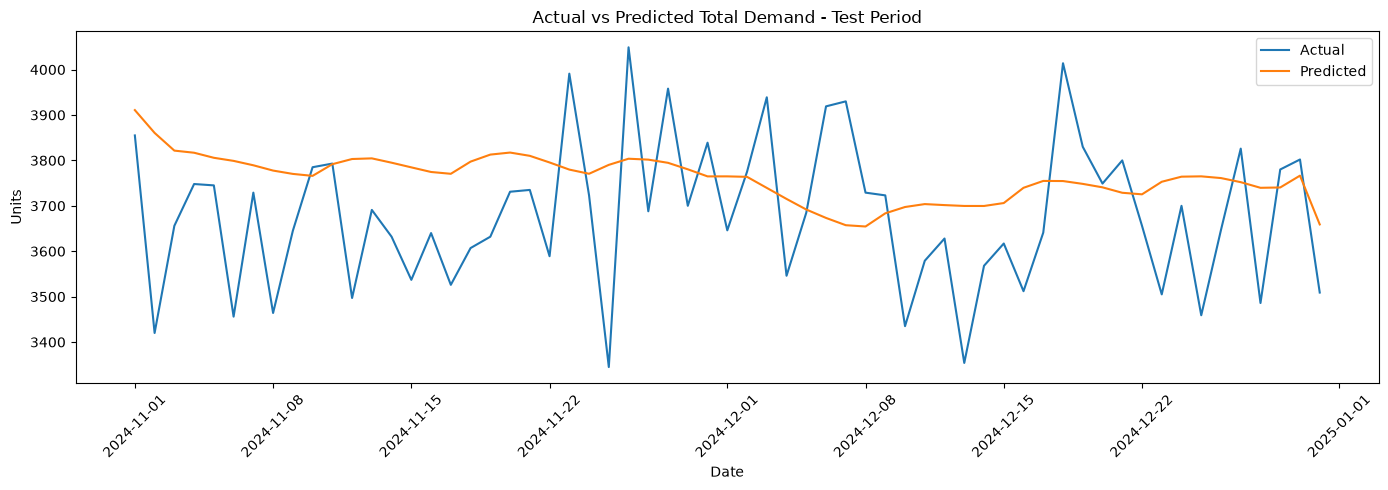

In [51]:
results = pd.DataFrame({
    "date": pd.to_datetime(test_dates),
    "sku": [k[0] for k in test_keys],
    "region": [k[1] for k in test_keys],
    "actual": y_test,
    "predicted": pred_test
}).sort_values("date")

overall_daily = results.groupby("date")[["actual", "predicted"]].sum()

plt.figure(figsize=(14,5))
plt.plot(overall_daily.index, overall_daily["actual"], label="Actual")
plt.plot(overall_daily.index, overall_daily["predicted"], label="Predicted")
plt.title("Actual vs Predicted Total Demand - Test Period")
plt.xlabel("Date")
plt.ylabel("Units")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 23. Example SKU × Region Forecast Performance

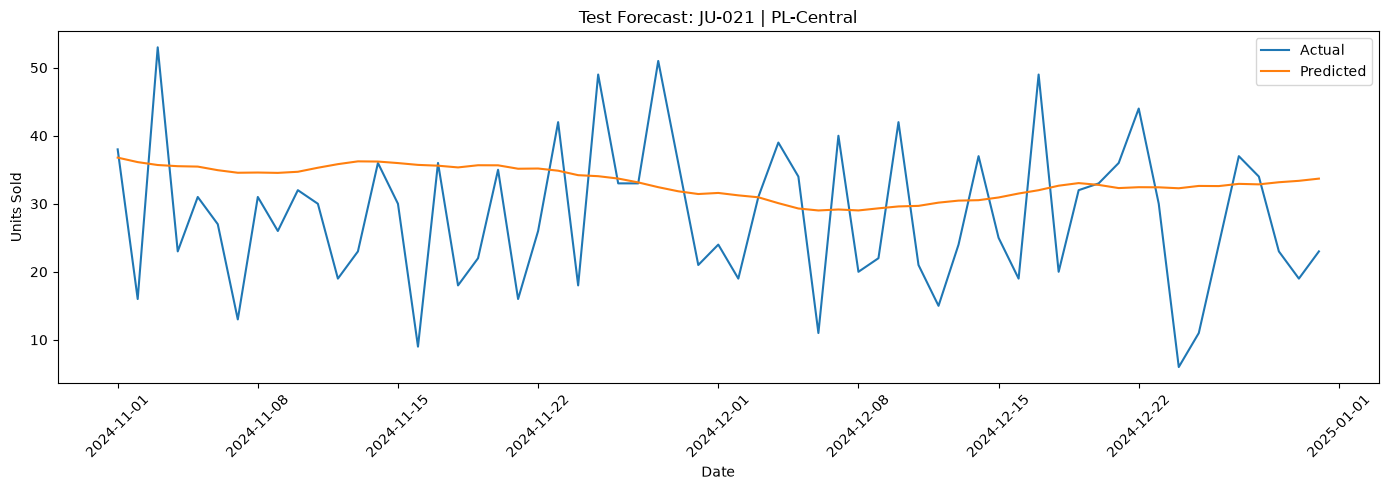

,date,sku,region,actual,predicted
0,2024-11-01,JU-021,PL-Central,37.999999,36.785417
1,2024-11-02,JU-021,PL-Central,16.000000,36.126119
2,2024-11-03,JU-021,PL-Central,52.999998,35.699372
3,2024-11-04,JU-021,PL-Central,23.000000,35.525365
4,2024-11-05,JU-021,PL-Central,31.000000,35.465915
5,2024-11-06,JU-021,PL-Central,27.000001,34.939087
6,2024-11-07,JU-021,PL-Central,13.000000,34.560925
7,2024-11-08,JU-021,PL-Central,31.000000,34.593326
8,2024-11-09,JU-021,PL-Central,25.999999,34.542575
9,2024-11-10,JU-021,PL-Central,31.999999,34.704922


In [52]:
example_key = results.groupby(["sku", "region"]).size().sort_values(ascending=False).index[0]
example = results[
    (results["sku"] == example_key[0]) &
    (results["region"] == example_key[1])
].sort_values("date")

plt.figure(figsize=(14,5))
plt.plot(example["date"], example["actual"], label="Actual")
plt.plot(example["date"], example["predicted"], label="Predicted")
plt.title(f"Test Forecast: {example_key[0]} | {example_key[1]}")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(example.head(15))


## 24. Error Analysis by SKU × Region

In [53]:
error_analysis = (
    results.assign(abs_error=lambda x: np.abs(x["actual"] - x["predicted"]))
           .groupby(["sku", "region"])
           .agg(
               actual_demand=("actual", "sum"),
               predicted_demand=("predicted", "sum"),
               MAE=("abs_error", "mean")
           )
           .reset_index()
           .sort_values("MAE", ascending=False)
)

display(error_analysis.head(15))


,sku,region,actual_demand,predicted_demand,MAE
34,RE-017,PL-North,3287.000005,3128.034086,20.958129
32,RE-015,PL-South,3127.999991,3106.900250,19.251653
31,RE-015,PL-North,3499.000004,3207.153630,18.832536
40,SN-010,PL-North,3051.999999,2971.700580,18.559351
36,RE-025,PL-Central,3189.999981,3057.908441,18.089754
25,RE-004,PL-North,3204.000006,3056.736908,17.983187
37,RE-025,PL-North,2980.999990,3116.507488,17.943248
33,RE-017,PL-Central,3483.999997,3167.228767,17.822542
26,RE-004,PL-South,3063.999989,3126.581407,17.549388
38,RE-025,PL-South,3203.999993,3143.524109,17.484289


## 25. Seven-Day Forecast Function

The trained model predicts one day at a time. For a 7-day forecast, each prediction is appended to the sequence and used as part of the next input.

For future operational variables (`price_unit`, promotion, stock, etc.), the dashboard uses the latest available context values as a simple planning assumption. This is clearly a scenario assumption, not a claim that future promotions/prices are known.

In [54]:
def prepare_series_for_forecast(frame, sku, region):
    g = frame[
        (frame["sku"] == sku) &
        (frame["region"] == region)
    ].sort_values(DATE_COL).copy()

    if len(g) < LOOKBACK:
        raise ValueError(f"Not enough history for {sku} / {region}. Need at least {LOOKBACK} rows.")

    return g

def recursive_forecast(model, fitted_scaler, frame, sku, region,
                       lookback=30, horizon=7):
    g = prepare_series_for_forecast(frame, sku, region).copy()

    # Work on a copy because lag/rolling features need to be updated after every prediction.
    history = g.copy()

    forecasts = []

    for step in range(horizon):
        last_date = history[DATE_COL].max()
        next_date = last_date + pd.Timedelta(days=1)

        # Construct future known/assumed features.
        recent = history.tail(7)

        new_row = {
            DATE_COL: next_date,
            "sku": sku,
            "region": region,
            "units_sold": np.nan,
            "price_unit": recent["price_unit"].mean(),
            "promotion_rate": recent["promotion_rate"].mean(),
            "stock_available": recent["stock_available"].iloc[-1],
            "delivered_qty": recent["delivered_qty"].mean(),
            "delivery_days": recent["delivery_days"].mean(),
            "day_of_week": next_date.dayofweek,
            "is_weekend": int(next_date.dayofweek >= 5),
            "month": next_date.month,
            "day_of_month": next_date.day
        }

        demand_values = history["units_sold"].dropna().values

        new_row["lag_1"] = demand_values[-1]
        new_row["lag_7"] = demand_values[-7] if len(demand_values) >= 7 else demand_values[-1]
        new_row["lag_14"] = demand_values[-14] if len(demand_values) >= 14 else demand_values[-1]
        new_row["lag_30"] = demand_values[-30] if len(demand_values) >= 30 else demand_values[-1]
        new_row["rolling_mean_7"] = np.mean(demand_values[-7:])
        new_row["rolling_mean_14"] = np.mean(demand_values[-14:])
        new_row["rolling_mean_30"] = np.mean(demand_values[-30:])

        feature_frame = history.tail(lookback)[FEATURE_COLS].copy()
        future_feature_frame = pd.DataFrame([new_row])[FEATURE_COLS]

        # Scale the historical sequence plus the current feature row.
        combined = pd.concat([feature_frame, future_feature_frame], ignore_index=True)
        combined_scaled = fitted_scaler.transform(combined.astype(float))

        # The model predicts next-day units_sold from the previous lookback days.
        x = combined_scaled[:lookback].reshape(1, lookback, len(FEATURE_COLS))
        pred_scaled = float(model.predict(x, verbose=0)[0, 0])
        pred_units = float(np.clip(inverse_target([pred_scaled], fitted_scaler)[0], 0, None))

        new_row["units_sold"] = pred_units
        history = pd.concat([history, pd.DataFrame([new_row])], ignore_index=True)

        forecasts.append({
            "date": next_date,
            "sku": sku,
            "region": region,
            "forecast_units": pred_units
        })

    return pd.DataFrame(forecasts)


## 26. Generate a Sample 7-Day Forecast

,date,sku,region,forecast_units
0,2025-01-01,JU-021,PL-Central,33.484323
1,2025-01-02,JU-021,PL-Central,32.728153
2,2025-01-03,JU-021,PL-Central,32.124572
3,2025-01-04,JU-021,PL-Central,31.799439
4,2025-01-05,JU-021,PL-Central,31.709377
5,2025-01-06,JU-021,PL-Central,32.111462
6,2025-01-07,JU-021,PL-Central,32.569050


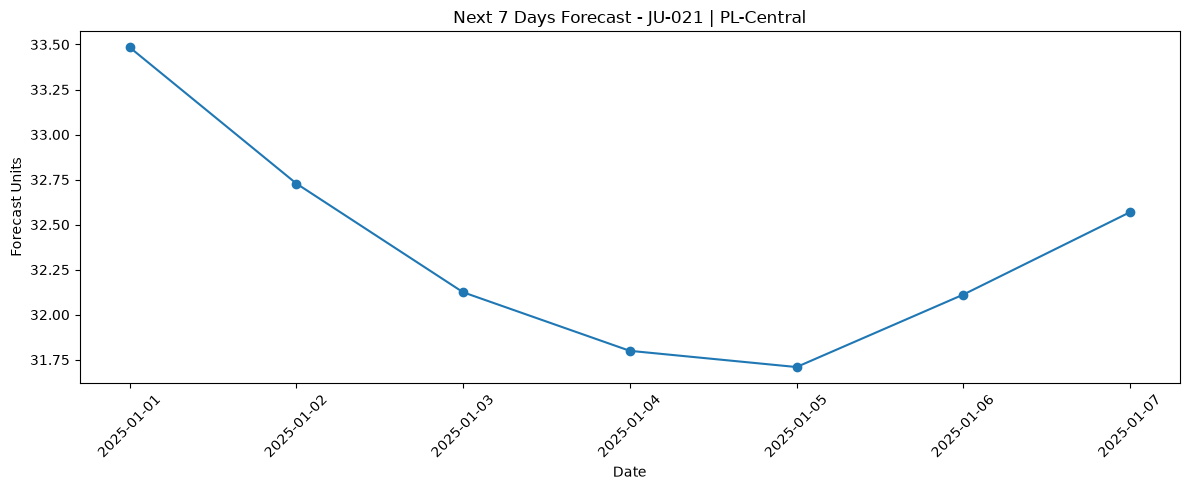

In [55]:
sample_sku = ts_model["sku"].iloc[0]
sample_region = ts_model["region"].iloc[0]

forecast_sample = recursive_forecast(
    model,
    scaler,
    ts_model,
    sample_sku,
    sample_region,
    lookback=LOOKBACK,
    horizon=FORECAST_HORIZON
)

display(forecast_sample)

plt.figure(figsize=(12,5))
plt.plot(forecast_sample["date"], forecast_sample["forecast_units"], marker="o")
plt.title(f"Next 7 Days Forecast - {sample_sku} | {sample_region}")
plt.xlabel("Date")
plt.ylabel("Forecast Units")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 27. Inventory Decision Support

The forecast can be combined with current stock to create a simple replenishment signal.

This is **decision support**, not an automated purchase order.

Rule:
- if current stock < forecasted 7-day demand → `REPLENISH`
- otherwise → `SUFFICIENT`

The current stock is taken from the latest available record for the selected SKU-region series.

In [56]:
def inventory_recommendation(frame, forecast_df, sku, region):
    g = frame[
        (frame["sku"] == sku) &
        (frame["region"] == region)
    ].sort_values(DATE_COL)

    current_stock = float(g["stock_available"].iloc[-1])
    forecast_demand = float(forecast_df["forecast_units"].sum())
    gap = forecast_demand - current_stock

    status = "REPLENISH" if gap > 0 else "SUFFICIENT"

    return pd.DataFrame({
        "SKU": [sku],
        "Region": [region],
        "Current Stock": [current_stock],
        "Next 7-Day Forecast Demand": [forecast_demand],
        "Estimated Stock Gap": [gap],
        "Inventory Signal": [status]
    })

inventory_result = inventory_recommendation(
    ts_model, forecast_sample, sample_sku, sample_region
)

display(inventory_result)


,SKU,Region,Current Stock,Next 7-Day Forecast Demand,Estimated Stock Gap,Inventory Signal
0,JU-021,PL-Central,419.0,226.526376,-192.473624,SUFFICIENT


## 28. Generate Forecasts for All SKU × Region Series

This creates a reusable forecast table for dashboard/deployment use.

In [57]:
forecast_all = []

series_keys = ts_model[["sku", "region"]].drop_duplicates().itertuples(index=False, name=None)

for sku, region in series_keys:
    try:
        fc = recursive_forecast(
            model, scaler, ts_model, sku, region,
            lookback=LOOKBACK, horizon=FORECAST_HORIZON
        )
        forecast_all.append(fc)
    except Exception as e:
        print(f"Skipped {sku} / {region}: {e}")

forecast_all_df = pd.concat(forecast_all, ignore_index=True)

print("Forecast rows:", len(forecast_all_df))
display(forecast_all_df.head(20))


Forecast rows: 630


,date,sku,region,forecast_units
0,2025-01-01,JU-021,PL-Central,33.484323
1,2025-01-02,JU-021,PL-Central,32.728153
2,2025-01-03,JU-021,PL-Central,32.124572
3,2025-01-04,JU-021,PL-Central,31.799439
4,2025-01-05,JU-021,PL-Central,31.709377
5,2025-01-06,JU-021,PL-Central,32.111462
6,2025-01-07,JU-021,PL-Central,32.569050
7,2025-01-01,JU-021,PL-North,33.076120
8,2025-01-02,JU-021,PL-North,32.281432
9,2025-01-03,JU-021,PL-North,31.455416


## 29. Inventory Alerts for All Series

In [58]:
latest_stock = (
    ts_model.sort_values(DATE_COL)
            .groupby(["sku", "region"], as_index=False)
            .tail(1)[["sku", "region", "stock_available"]]
            .rename(columns={"stock_available": "current_stock"})
)

seven_day_summary = (
    forecast_all_df.groupby(["sku", "region"], as_index=False)["forecast_units"]
                   .sum()
                   .rename(columns={"forecast_units": "forecast_7d_demand"})
)

inventory_alerts = seven_day_summary.merge(
    latest_stock, on=["sku", "region"], how="left"
)

inventory_alerts["stock_gap"] = (
    inventory_alerts["forecast_7d_demand"] -
    inventory_alerts["current_stock"]
)

inventory_alerts["signal"] = np.where(
    inventory_alerts["stock_gap"] > 0,
    "REPLENISH",
    "SUFFICIENT"
)

inventory_alerts = inventory_alerts.sort_values(
    "stock_gap", ascending=False
)

display(inventory_alerts.head(20))


,sku,region,forecast_7d_demand,current_stock,stock_gap,signal
39,SN-010,PL-Central,340.975900,0.0,340.975900,REPLENISH
40,SN-010,PL-North,355.533626,131.0,224.533626,REPLENISH
33,RE-017,PL-Central,414.392017,200.0,214.392017,REPLENISH
38,RE-025,PL-South,396.037720,238.0,158.037720,REPLENISH
60,YO-003,PL-Central,322.826871,173.0,149.826871,REPLENISH
25,RE-004,PL-North,401.450005,257.0,144.450005,REPLENISH
36,RE-025,PL-Central,391.388777,255.0,136.388777,REPLENISH
45,SN-019,PL-Central,334.033462,234.0,100.033462,REPLENISH
34,RE-017,PL-North,370.560605,290.0,80.560605,REPLENISH
22,MI-026,PL-North,318.960817,247.0,71.960817,REPLENISH


## 30. Save Model and Deployment Artifacts

The following files are saved so a Streamlit app can reuse the trained model without retraining:
- Keras model
- scaler
- feature configuration
- processed time-series data
- forecast output

In [59]:
import joblib
import json

model_path = os.path.join(MODEL_DIR, "lstm_demand_model.keras")
scaler_path = os.path.join(MODEL_DIR, "feature_scaler.pkl")
data_path = os.path.join(MODEL_DIR, "forecast_source_data.csv")
forecast_path = os.path.join(MODEL_DIR, "forecast_7day_all.csv")
config_path = os.path.join(MODEL_DIR, "config.json")

model.save(model_path)
joblib.dump(scaler, scaler_path)

ts_model.to_csv(data_path, index=False)
forecast_all_df.to_csv(forecast_path, index=False)

config = {
    "date_col": DATE_COL,
    "target_col": TARGET_COL,
    "group_cols": GROUP_COLS,
    "feature_cols": FEATURE_COLS,
    "lookback": LOOKBACK,
    "forecast_horizon": FORECAST_HORIZON,
    "target_index": TARGET_INDEX
}

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=4)

print("Saved:")
for p in [model_path, scaler_path, data_path, forecast_path, config_path]:
    print(" -", p)


Saved:
 - fmcg_lstm_artifacts\lstm_demand_model.keras
 - fmcg_lstm_artifacts\feature_scaler.pkl
 - fmcg_lstm_artifacts\forecast_source_data.csv
 - fmcg_lstm_artifacts\forecast_7day_all.csv
 - fmcg_lstm_artifacts\config.json


In [ ]:
## 

## 31. Save Evaluation Results

In [60]:
metrics_path = os.path.join(MODEL_DIR, "evaluation_metrics.csv")
metrics.to_csv(metrics_path, index=False)

results_path = os.path.join(MODEL_DIR, "test_predictions.csv")
results.to_csv(results_path, index=False)

alerts_path = os.path.join(MODEL_DIR, "inventory_alerts.csv")
inventory_alerts.to_csv(alerts_path, index=False)

print("Evaluation, prediction and inventory files saved.")


Evaluation, prediction and inventory files saved.


## 32. Generate `requirements.txt` for VS Code / Deployment

In [61]:
requirements = [
    "pandas>=2.0",
    "numpy>=1.24",
    "matplotlib>=3.7",
    "seaborn>=0.12",
    "scikit-learn>=1.3",
    "tensorflow>=2.15",
    "joblib>=1.3",
    "streamlit>=1.30"
]

requirements_path = os.path.join(MODEL_DIR, "requirements.txt")

with open(requirements_path, "w", encoding="utf-8") as f:
    f.write("\n".join(requirements))

print(open(requirements_path, encoding="utf-8").read())


pandas>=2.0
numpy>=1.24
matplotlib>=3.7
seaborn>=0.12
scikit-learn>=1.3
tensorflow>=2.15
joblib>=1.3
streamlit>=1.30


# 33. Final Project Summary

### What was built
- FMCG daily demand time-series preparation
- SKU × Region level forecasting
- Time-based feature engineering
- Leakage-safe chronological train/validation/test split
- Naive baseline
- Global LSTM model
- Next-day learning with recursive 7-day forecasting
- MAE, RMSE and MAPE evaluation
- Actual vs predicted visualization
- SKU × Region error analysis
- Inventory replenishment signal
- Deployment-ready model/scaler/config artifacts

### Important interpretation
The LSTM forecast is a **planning estimate**, not a guaranteed future sales value. Inventory alerts are decision-support signals and should be validated against business rules, lead times and actual replenishment constraints.

### Next Production Layer
A Streamlit application can load the saved `.keras` model, scaler and source data, let a user select SKU + region, display the next 7-day forecast, and show the inventory signal.
